In [2]:
import re
from tqdm import tqdm #Progress Indication
from pprint import pprint,pformat #Saubere JSON darstellung

import numpy as np 
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import defaultdict
from collections import Counter

import spacy # Lemmatizer

import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from GerVADER.vaderSentimentGER import SentimentIntensityAnalyzer as GerSentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.styles import *
from src.visualization import *

**Beschriebenes Vorgehen:**

Bereinigung durch:
- Pandas
- NLTK
- SpaCy (besser für Deutsches Lemmatizing)

-> Separat für Topic Modeling/ Semantik Analyse


Vektorisierung anhand BoW und TF-IDF + n-Gramme durch:
- sklearn

-> Darstellung Unterschied zwischen BoW u TF-IDF
-> TF-IDF sprachsepariert, da sonst falsche stoppwörter


Themenidentifikation (LSA/LDA) durch:
- sklearn
- vaderSentiment
- GerVADER

-> Ausarbeitung bester Ansatz:

BoW + LDA
TF-IDF + LDA
-> TF-IDF + LSA



In [3]:
def batch_lemmatizer(texts, nlp, stopw, desc, n_process):
    sentences = []

    reviews = nlp.pipe(texts, batch_size=200, n_process=n_process)

    for review in tqdm(reviews, total=len(texts), desc=desc):
        lemmas = [
            token.lemma_.lower()
            for token in review
            if token.is_alpha
            and len(token) > 2
            and not token.is_stop
            and token.lemma_.lower() not in stopw
        ]

        if lemmas:
            sentences.append(lemmas)

    return sentences
            
def clean_and_tokenize(df, stopw_de, stopw_en, n_process):
    stopw_de = set(stopw_de)
    stopw_en = set(stopw_en)

    nlp_de = spacy.load("de_core_news_sm", disable=["parser", "ner"])
    nlp_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])

    df_de = df[df["language"] == "de"]["review"].fillna("").astype(str)
    df_en = df[df["language"] == "en"]["review"].fillna("").astype(str)

    result = {}

    for lang, texts, nlp, stopw, desc in [
        ("de", df_de, nlp_de, stopw_de, "Deutsch verarbeiten"),
        ("en", df_en, nlp_en, stopw_en, "Englisch verarbeiten"),
    ]:
        sentences = batch_lemmatizer(
            texts=texts,
            nlp=nlp,
            stopw=stopw,
            desc=desc,
            n_process=n_process
        )

        documents = [" ".join(sentence) for sentence in sentences]
        vocabulary = sorted(set(word for sent in sentences for word in sent))
        index = {word: i for i, word in enumerate(vocabulary)}

        result[lang] = {
            "sentences": sentences,
            "documents": documents,
            "vocabulary": vocabulary,
            "index": index
        }

    return result

def vectorize(Vectorizer, data_by_lang):
    params = {
        "ngram_range": (1, 2),
        "min_df": 3,
        "max_df": 0.8,
        "dtype": np.float32,
    }

    results = {}

    for lang, data in data_by_lang.items():
        documents = data["documents"]

        vectorizer = Vectorizer(**params)
        matrix = vectorizer.fit_transform(documents)

        results[lang] = {
            "matrix": matrix,
            "vectorizer": vectorizer,
            "feature_names": vectorizer.get_feature_names_out(),
            "documents": documents,
            "sentences": data["sentences"],
            "vocabulary": data["vocabulary"],
            "index": data["index"]
        }

        print(f"{lang}: {matrix.shape[0]} Dokumente, {matrix.shape[1]} Features")

    return results

def assign_topics_with_keywords(model_result, method, n_top_words=10):
    """
    Einheitliche Topic-Zuordnung für LDA und LSA inkl. Top-Keywords.

    Erwartet in model_result:
        - "doc_topic_matrix"
        - "documents"
        - "model"
        - "features"

    Parameter:
        method (str): 'lda' oder 'lsa'
        n_top_words (int): Anzahl Top-Wörter pro Topic

    Rückgabe:
        DataFrame mit:
        - document
        - dominant_topic
        - topic_strength
        - topic_keywords
    """

    doc_topic_matrix = model_result["doc_topic_matrix"]

    # --- Topic-Zuordnung ---
    if method == "lda":
        dominant_topics = doc_topic_matrix.argmax(axis=1)
        topic_strengths = doc_topic_matrix.max(axis=1)

    elif method == "lsa":
        dominant_topics = np.abs(doc_topic_matrix).argmax(axis=1)
        topic_strengths = np.abs(doc_topic_matrix).max(axis=1)

    else:
        raise ValueError("method muss 'lda' oder 'lsa' sein")

    # --- Keywords pro Topic ---
    model = model_result["model"]
    features = model_result["features"]

    topic_keywords = {
        i + 1: ", ".join(
            features[j]
            for j in topic.argsort()[-n_top_words:][::-1]
        )
        for i, topic in enumerate(model.components_)
    }

    # --- DataFrame ---
    df = pd.DataFrame({
        "document": model_result["documents"],
        "dominant_topic": dominant_topics + 1,
        "topic_strength": topic_strengths
    })

    # Keywords mappen
    df["topic_keywords"] = df["dominant_topic"].map(topic_keywords)

    return df

def build_sentiment_df(model_result, lang, pos=0.05, neg=-0.05):
    """
    Berechnet Sentiment Score + Label pro Dokument.

    Parameter:
        model_result: enthält 'documents'
        lang: 'de' oder 'en'
        pos/neg: Schwellenwerte für Klassifikation

    Rückgabe:
        DataFrame mit:
        - document
        - sentiment_score
        - sentiment_label
    """

    analyzer_en = SentimentIntensityAnalyzer()
    analyzer_de = GerSentimentIntensityAnalyzer()
    
    documents = model_result["documents"]

    # richtigen Analyzer wählen
    if lang == "en":
        analyzer = analyzer_en
    elif lang == "de":
        analyzer = analyzer_de
    else:
        raise ValueError("Unsupported language")

    # Scores berechnen
    scores = [
        analyzer.polarity_scores(doc)["compound"]
        for doc in documents
    ]

    # DataFrame erstellen
    df = pd.DataFrame({
        "document": documents,
        "sentiment_score": scores
    })

    # Label direkt inline
    df["sentiment_label"] = df["sentiment_score"].apply(
        lambda s: "positive" if s >= pos else "negative" if s <= neg else "neutral"
    )

    return df


In [4]:
##########
# Variable Definition
##########
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"

# Manuelle Stopwörter (werden iterativ ergänzt) 
stopw_topic_manual_de, stopw_sentiment_manual_de = [],[]
stopw_topic_manual_en, stopw_sentiment_manual_en = [],[]

# Stoppwörter aus NTLK
stopw_de = stopwords.words("german")
stopw_en = stopwords.words("english") 

# Zusammengesetzte Stopwörter aus manuell und NTLK
stopw_topic_de = stopw_de + stopw_topic_manual_de
stopw_topic_en = stopw_en + stopw_topic_manual_en
stopw_sentiment_de = stopw_de + stopw_sentiment_manual_de
stopw_sentiment_en = stopw_en + stopw_sentiment_manual_en

############
# Import data to pandas dataframe
############
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

############
# Prepare Data
############

# --- Stopwort-Definitionen ---
stopword_updates = {
    "iter_1": {
        "de_common": [
            "august","information","art","aktuell","zahl","genannt","frage","antwort","fall",
            "stelle","rahmen","bitten","insbesondere","erachten","tatsächlich",
            "bayerisch","bayern","baydsg","bayuig","vig", # Verwaltungsbegriffe
            "lebensmittelbetriebe","routinekontrolle","rüb","avv","lfgb" # Standardanfragen
        ],
        "en_common": [
            "want","look","know","think","people","day","find","tell","ask","take","work"
        ],
        "en_topic_only": [
            "nice","well","delicious","friendly","definitely"
        ]
    },

    "iter_2": {
        "de_common": [
            "bitte","einschließlich","datum","folgend","liegen","antrag","behörde","anfrage",
            "projekt","dokument","erfolgen","zuständig","zuständigkeitsbereich","falls",
            "auskunft","entsprechend","befinden","angabe","betreffen",
            "elektronisch","öffentlich","soweit","überprüfen","registriert", # Juristisch
            "aktenauskunft","gesetz","umweltinformationsgesetz" # Juristisch
        ],
        "en_common": [
            "place","food","get","try","time","come","go",
            "need","way","say","staff","experience"
        ],
        "en_topic_only": [
            "good","great","like","love","little"
        ]
    },

    "iter_3": { 
        "de_common": [ # Hauptsächlich Verwaltungsfloskeln 
            "letzter","form","begründung","interesse",
            "sämtlicher","anzahl","gemeinde","handeln",
            "geplant","sinn","monat", "freundlich",
            "senden","mitteilen","grüße","häufig"
            "stellen","höhe","angeben"
        ],
        "en_common": [ 
            "lot","feel","thing","visit", "pretty",
            "long","area","minute","new"
        ],
        "en_topic_only": ["bad","amazing"]
    },
    
    "iter_4": { 
        "de_common": [ 
            "unverzüglich", "ausdrücklich", "häufig", 
            "vorab", "bewerten", "übersicht", "jährlich", "mühe",
            "danken", "verweisen", "zugänglich"
        ],
        "en_common": [ 
            "sure", "right", "review", "hour","leave"
        ],
        "en_topic_only": ["recommend", "enjoy"]
    },
    
    "iter_5": { # Nach BoW + LDA Topic Modeling
        "de_common": [ 
            "satz", "empfangsbestätigung", "widersprechen", "weiterzuleiten",
            "unterrichten", "weitergabe", "aufwand", "gebührenpflichtig",
            "herr", "geehrt", "dame", "gemäß", "beantragen","gmbh",
            "vorhanden", "vorliegen", "zugang", "angefragt",
            "gewähren", "fragdenstaat", "verfahren", "gesetzlich",
            "grund", "bezug", "mitteilung"
        ],
        "en_common": [],
        "en_topic_only": []
    },

    "iter_6": { # Nach 2tem BoW + LDA Topic Modeling Durchlauf
        "de_common": [ 
            "einfach", "somit", "spätestens", "stellen",
            "zusätzlich", "sofern", "aufgrund"
        ],
        "en_common": [],
        "en_topic_only": []
    }
}

for iteration in stopword_updates.values():

    # Deutsch (immer beide)
    stopw_topic_de += iteration["de_common"]
    stopw_sentiment_de += iteration["de_common"]

    # Englisch (gemeinsam)
    stopw_topic_en += iteration["en_common"]
    stopw_sentiment_en += iteration["en_common"]

    # Englisch (nur Topic)
    stopw_topic_en += iteration["en_topic_only"]

# ggf. Duplikate entfernen
stopw_topic_de = sorted(set(stopw_topic_de))
stopw_sentiment_de = sorted(set(stopw_sentiment_de))
stopw_topic_en = sorted(set(stopw_topic_en))
stopw_sentiment_en = sorted(set(stopw_sentiment_en))


# Daten für Topic Modeling
print("Cleaning Data - Topic Modeling")
data_topic = clean_and_tokenize(
    df_reviews,
    stopw_de=stopw_topic_de,
    stopw_en=stopw_topic_en,
    n_process=2 # ggf. Anpassen für schnellere Verarbeitung
)

# Daten für Sentimentanalyse
print("\nCleaning Data - Sentiment Analysis")
data_sentiment = clean_and_tokenize(
    df_reviews,
    stopw_de=stopw_sentiment_de,
    stopw_en=stopw_sentiment_en,
    n_process=2
)




Cleaning Data - Topic Modeling


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 76.66it/s]



Cleaning Data - Sentiment Analysis


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 76.43it/s]


In [5]:
top_n = 15
compare_top_tokens_table = compare_top_tokens(data_topic, data_sentiment, top_n)
display(style_compare_top_tokens(compare_top_tokens_table, caption=f"Top {top_n} Tokens: Topic vs Sentiment (de/en)"))

In [6]:
############
# Create Vectors with BoW & TF-IDF
# Separate Pipelines: Topic Modeling vs. Sentiment
############

print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 1000 Dokumente, 3774 Features
en: 1000 Dokumente, 2416 Features
de: 1000 Dokumente, 3774 Features
en: 1000 Dokumente, 2416 Features

Creating Vectors - Sentiment Analysis
de: 1000 Dokumente, 3774 Features
en: 1000 Dokumente, 2641 Features
de: 1000 Dokumente, 3774 Features
en: 1000 Dokumente, 2641 Features


In [8]:
############
# Topic Modeling
############

# Zentrale Parameter für alle Topic-Modelle
n_topics = 10          # Anzahl der Topics
n_top_words = 15       # Anzahl der Top-Wörter pro Topic
max_iter = 20          # Anzahl der Trainingsdurchläufe für LDA
batch_size = 500       # Batch-Größe für das Online-Learning bei LDA

# Zentrale Konfiguration aller Topic-Modelle
methods = {
    "bow_lda": {
        "title": "LDA BoW",
        "vectors_by_lang": vectors_topic["bow_by_lang"],
        "method_type": "lda",
    },
    "tfidf_lda": {
        "title": "LDA TF-IDF",
        "vectors_by_lang": vectors_topic["tfidf_by_lang"],
        "method_type": "lda",
    },
    "tfidf_lsa": {
        "title": "LSA TF-IDF",
        "vectors_by_lang": vectors_topic["tfidf_by_lang"],
        "method_type": "lsa",
    },
}

# Jedes konfigurierte Modell trainieren
for method_key, config in methods.items():

    # Hier werden die trainierten Ergebnisse je Sprache gespeichert
    config["topics_by_lang"] = {}

    # Sprachgetrenntes Training, für "de" und "en"
    for lang, data in config["vectors_by_lang"].items():
        X = data["matrix"]  # Dokument-Term-Matrix der jeweiligen Sprache

        # LDA-Modell trainieren - Für BoW und TF-IDF mit den selben Werten
        if config["method_type"] == "lda":
            model = LatentDirichletAllocation(
                n_components=n_topics,
                random_state=42,
                learning_method="online",
                max_iter=max_iter,
                evaluate_every=-1
            )

            # Manuelles Online-Training über mehrere Iterationen und Batches
            for _ in tqdm(range(max_iter), desc=f'{config["title"]} Topic trainieren ({lang})'):
                for i in range(0, X.shape[0], batch_size):
                    model.partial_fit(X[i:i + batch_size])

            # Dokumente in Topic-Wahrscheinlichkeiten transformieren
            topic_matrix = model.transform(X)

        # LSA-Modell trainieren
        elif config["method_type"] == "lsa":
            model = TruncatedSVD(
                n_components=n_topics,
                random_state=42
            )

            # Dokumente direkt in latente Topic-Komponenten transformieren
            topic_matrix = model.fit_transform(X)
            print(f'{config["title"]} Topic trainiert ({lang})')


        # Modell- und Ergebnisdaten zentral im methods-Dict speichern
        config["topics_by_lang"][lang] = {
            "model": model,
            "doc_topic_matrix": topic_matrix,
            "matrix": X,
            "features": data["feature_names"],
            "documents": data["documents"]
        }

LDA TF-IDF Topic trainieren (en): 100%|████████████████████████████████████████████████| 20/20 [00:03<00:00,  6.42it/s]


LSA TF-IDF Topic trainiert (de)
LSA TF-IDF Topic trainiert (en)


In [9]:
def get_structure(d, max_depth=3, current_depth=0):
    if current_depth >= max_depth:
        return "..."

    if isinstance(d, dict):
        return {
            k: get_structure(v, max_depth, current_depth + 1)
            for k, v in d.items()
        }

    return type(d).__name__


pprint(get_structure(next(iter(methods.values())), max_depth=3))

{'method_type': 'str',
 'title': 'str',
 'topics_by_lang': {'de': {'doc_topic_matrix': '...',
                           'documents': '...',
                           'features': '...',
                           'matrix': '...',
                           'model': '...'},
                    'en': {'doc_topic_matrix': '...',
                           'documents': '...',
                           'features': '...',
                           'matrix': '...',
                           'model': '...'}},
 'vectors_by_lang': {'de': {'documents': '...',
                            'feature_names': '...',
                            'index': '...',
                            'matrix': '...',
                            'sentences': '...',
                            'vectorizer': '...',
                            'vocabulary': '...'},
                     'en': {'documents': '...',
                            'feature_names': '...',
                            'index': '...',
         

In [10]:
############
# Topic + Sentiment Analyse
############


# 1. Topic-Zuordnung je Modell
doc_topics = {
    method: {
        lang: assign_topics_with_keywords(
            result,
            method=config["method_type"]
        )
        for lang, result in config["topics_by_lang"].items()
    }
    for method, config in methods.items()
}

# 2. Sentiment je Sprache berechnen
# Sentiment basiert auf den Sentiment-Dokumenten, nicht auf BoW/TF-IDF
sentiments = {
    lang: build_sentiment_df(result, lang=lang)
    for lang, result in vectors_sentiment["tfidf_by_lang"].items()
}

# 3. Topic-Zuordnung + Sentiment verbinden
doc_topics_sentiment = {
    method: {
        lang: df_topics.merge(
            sentiments[lang],
            on="document",
            how="left"
        )
        for lang, df_topics in lang_results.items()
    }
    for method, lang_results in doc_topics.items()
}

# 4. Aggregierte Topic/Sentiment-Tabelle je Modell
topic_sentiment_summary = {
    method: {
        lang: (
            df.groupby("dominant_topic")
            .agg(
                documents=("document", "count"),
                avg_sentiment=("sentiment_score", "mean"),
                positive=("sentiment_label", lambda x: (x == "positive").sum()),
                neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
                negative=("sentiment_label", lambda x: (x == "negative").sum())
                #topic_keywords=("topic_keywords", "first")
            )
            .reset_index()
        )
        for lang, df in lang_results.items()
    }
    for method, lang_results in doc_topics_sentiment.items()
}

In [11]:
# 5. Ausgabe: BoW/LDA Topic + Sentiment

for lang in ["de", "en"]:
    if lang == "de":
        pos_threshold, neg_threshold = 0.5, -0.5
    elif lang == "en":
        pos_threshold, neg_threshold = 0.1, -0.1

    for method_key, config in methods.items():
        display(style_topic_sentiment(
            topic_sentiment_summary[method_key][lang],
            f"{config["title"]} ({lang}) - Topic & Sentiment Matrix",
            pos_threshold=pos_threshold,
            neg_threshold=neg_threshold
        ))

dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,3790,0.509224,3775,5,10
2,330,0.629269,275,28,27
3,376,0.161292,95,272,9
4,9026,-0.862404,0,1,9025
5,44,0.332309,29,7,8
6,121,0.284903,60,47,14
7,384,0.273303,324,27,33
8,127,0.737516,120,6,1
9,164,0.766540,140,17,7
10,30,0.768963,25,5,0


dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,679,0.295173,410,267,2
2,276,0.713903,243,24,9
3,123,0.497493,100,10,13
4,9026,-0.862404,0,1,9025
5,61,0.589321,43,15,3
6,169,0.284769,107,19,43
7,83,0.356799,55,15,13
8,147,0.540519,106,36,5
9,3707,0.507387,3689,7,11
10,121,0.512999,90,21,10


dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,9041,-0.860765,5,8,9028
2,3395,0.523982,3377,6,12
3,525,0.515624,408,65,52
4,90,0.458298,80,8,2
5,79,0.147247,27,42,10
6,291,0.047350,24,261,6
7,84,0.526356,68,5,11
8,206,0.167028,200,2,4
9,332,0.340019,328,4,0
10,349,0.816844,326,14,9


dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,89,0.170443,3,2,2
2,69,-0.036443,2,1,4
3,78,0.442750,6,0,2
4,197,0.154273,6,1,4
5,62,-0.155963,1,1,6
6,90,-0.025100,3,1,3
7,85,0.818867,3,0,0
8,84,0.341940,4,0,1
9,138,-0.087545,5,0,6
10,108,0.144400,9,1,6


dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,121,0.014700,4,0,4
2,68,0.072671,3,0,4
3,45,0.866950,2,0,0
4,185,-0.086800,2,1,4
5,137,0.001271,5,3,9
6,92,0.136330,5,1,4
7,78,0.688000,6,0,0
8,82,0.351850,4,0,2
9,67,-0.106300,2,0,2
10,125,0.082244,9,2,5


dominant_topic,documents,avg_sentiment,positive,neutral,negative
1,615,0.082061,19,2,17
2,76,0.120590,5,1,4
3,39,0.002517,2,1,3
4,28,0.690800,1,0,0
5,40,0.109425,2,0,2
6,33,0.509267,2,0,1
7,12,nan,0,0,0
8,46,-0.075250,1,1,2
9,37,0.261440,3,1,1
10,74,0.188792,7,1,4


In [71]:
# 6. Ausgabe: Topics per Method/ Language
topic_table_de = build_topic_comparison_tables(doc_topics,methods,"de")
topic_table_en = build_topic_comparison_tables(doc_topics,methods,"en")

#display(style_topic_comparison(topic_table_de, "Topic Vergleich - DE"))
#print()
#display(style_topic_comparison(topic_table_en, "Topic Vergleich - EN"))


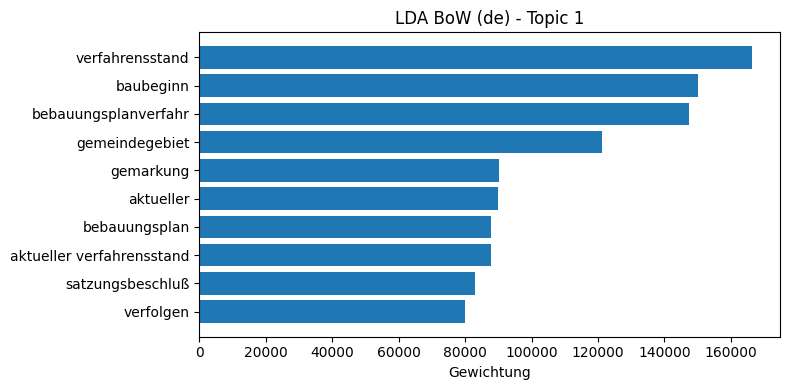

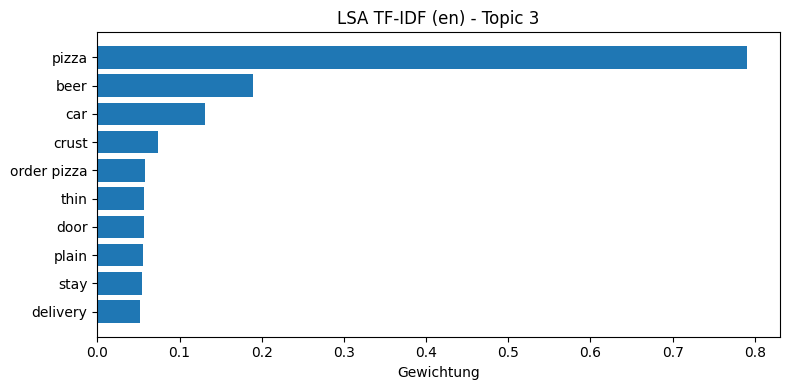

In [73]:
def plot_top_words_from_methods(methods, method_key, lang, topic_id, n_words=10):
    data = methods[method_key]["topics_by_lang"][lang]

    model = data["model"]
    features = data["features"]

    weights = model.components_[topic_id]
    top_idx = weights.argsort()[-n_words:][::-1]

    words = [features[i] for i in top_idx]
    values = [weights[i] for i in top_idx]

    plt.figure(figsize=(8, 4))
    plt.barh(words[::-1], values[::-1])
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic {topic_id + 1}')
    plt.xlabel("Gewichtung")
    plt.tight_layout()
    plt.show()

plot_top_words_from_methods(methods, "bow_lda", "de", topic_id=0)
plot_top_words_from_methods(methods, "tfidf_lsa", "en", topic_id=2)

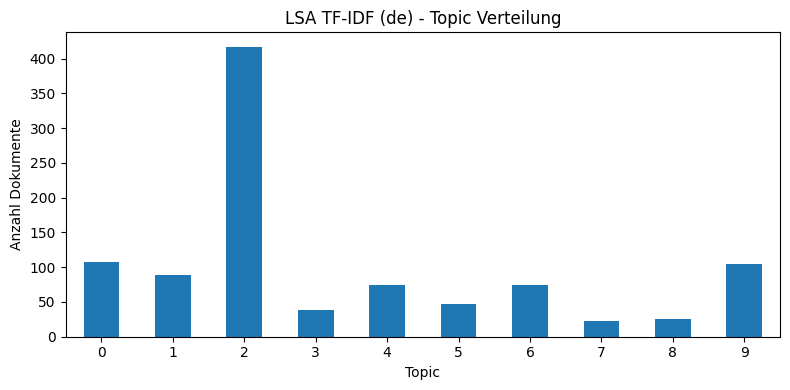

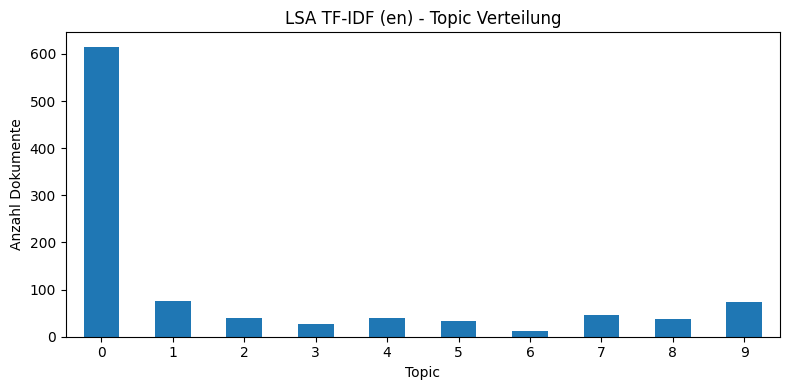

In [75]:
def plot_topic_distribution_from_methods(methods, method_key, lang):
    data = methods[method_key]["topics_by_lang"][lang]
    doc_topic_matrix = data["doc_topic_matrix"]

    if methods[method_key]["method_type"] == "lsa":
        doc_topic_matrix = np.abs(doc_topic_matrix)

    dominant_topics = doc_topic_matrix.argmax(axis=1)

    counts = (
        pd.Series(dominant_topics)
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    counts.plot(kind="bar")
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic Verteilung')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_distribution_from_methods(methods, "tfidf_lsa", "de")
plot_topic_distribution_from_methods(methods, "tfidf_lsa", "en")

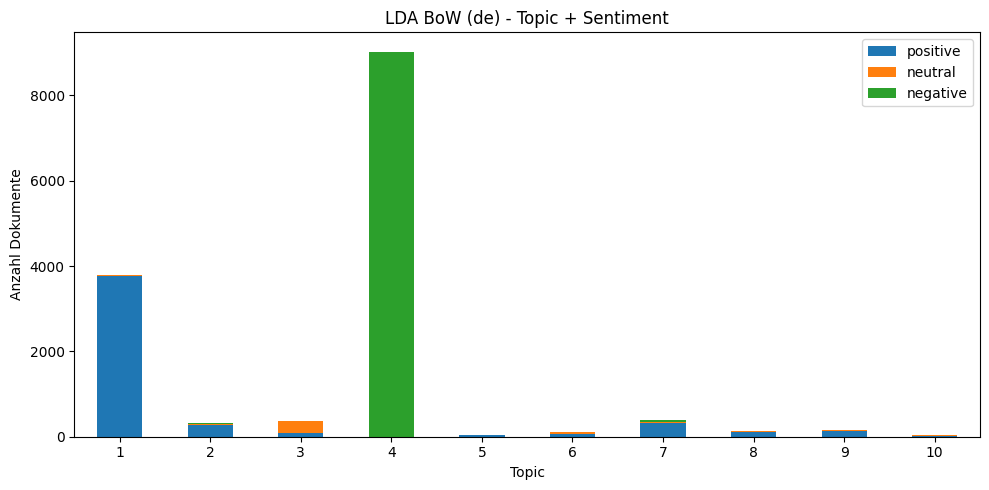

In [76]:
def plot_topic_sentiment_from_summary(summary, method_key, lang):
    df = summary[method_key][lang]

    plot_df = df.set_index("dominant_topic")[[
        "positive", "neutral", "negative"
    ]]

    plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic + Sentiment')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_sentiment_from_summary(topic_sentiment_summary, "bow_lda", "de")

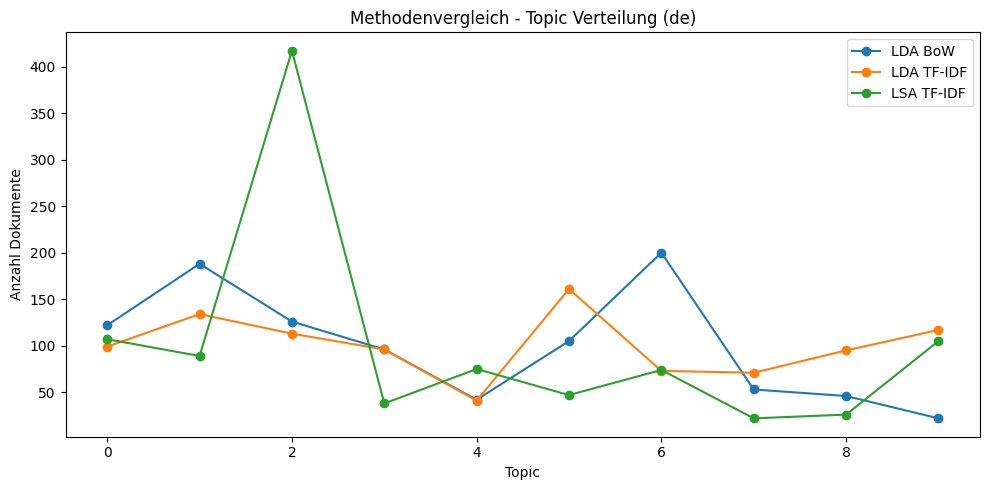

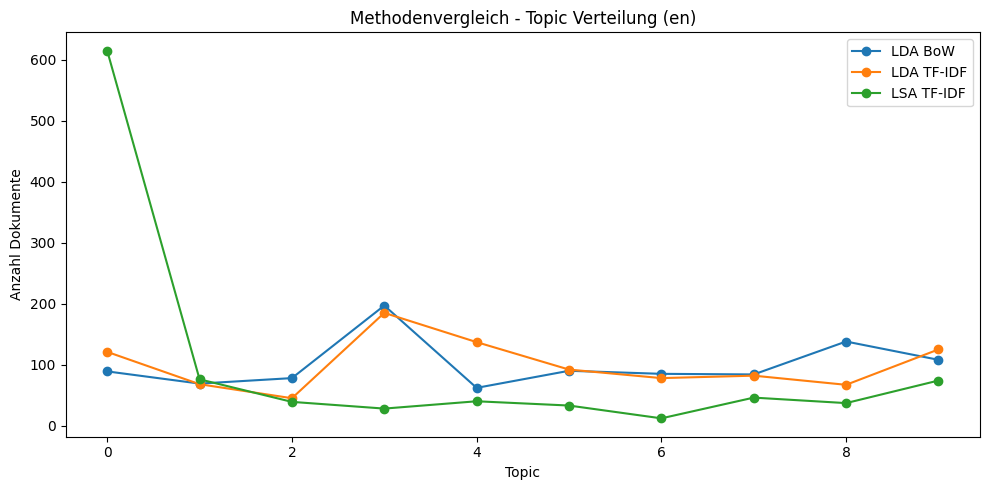

In [77]:
def compare_methods_topic_distribution(methods, lang):
    plt.figure(figsize=(10, 5))

    for method_key, config in methods.items():
        data = config["topics_by_lang"][lang]
        doc_topic_matrix = data["doc_topic_matrix"]

        if config["method_type"] == "lsa":
            doc_topic_matrix = np.abs(doc_topic_matrix)

        dominant_topics = doc_topic_matrix.argmax(axis=1)
        counts = pd.Series(dominant_topics).value_counts().sort_index()

        plt.plot(counts.index, counts.values, marker="o", label=config["title"])

    plt.title(f"Methodenvergleich - Topic Verteilung ({lang})")
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_methods_topic_distribution(methods, "de")
compare_methods_topic_distribution(methods, "en")

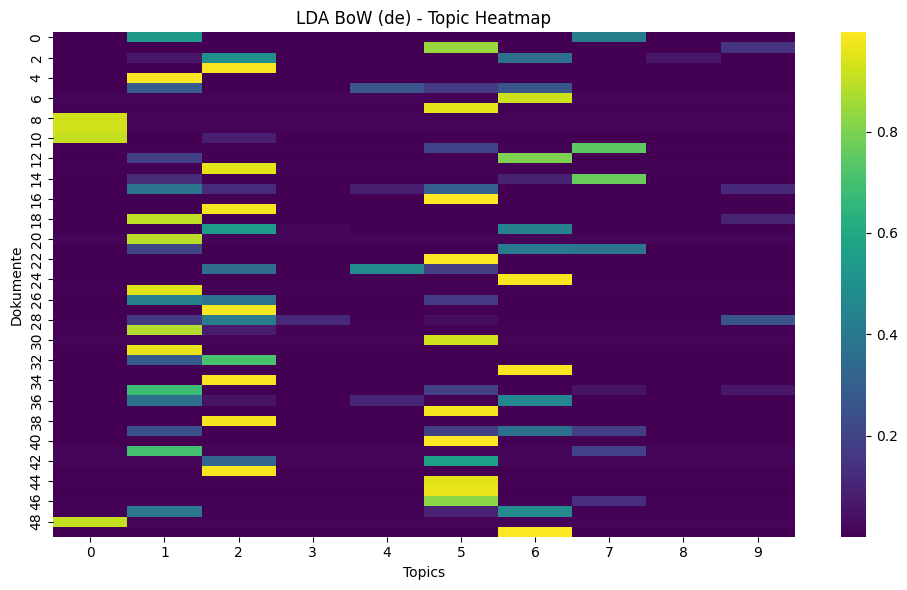

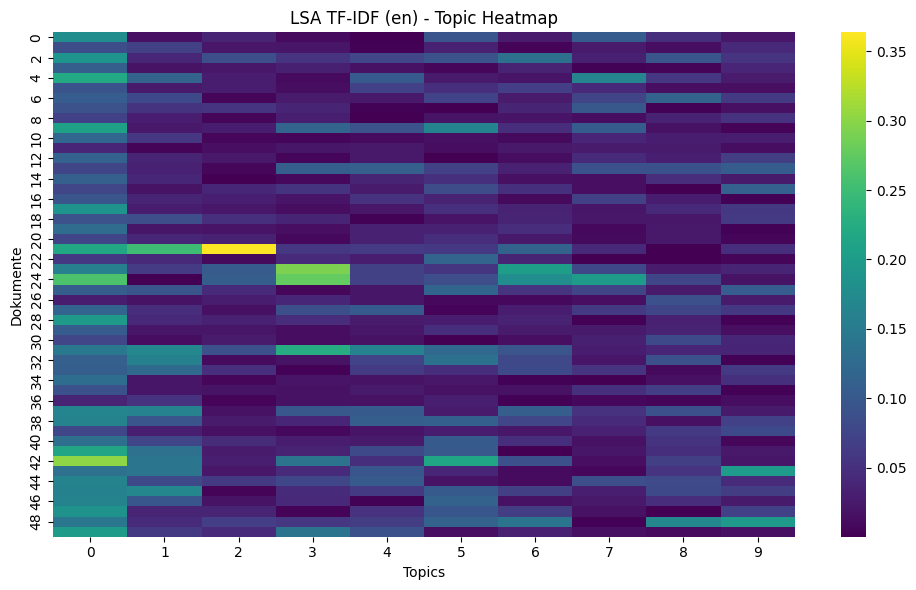

In [79]:


def plot_topic_heatmap(methods, method_key, lang):
    data = methods[method_key]["topics_by_lang"][lang]
    matrix = data["doc_topic_matrix"]

    if methods[method_key]["method_type"] == "lsa":
        matrix = np.abs(matrix)

    plt.figure(figsize=(10, 6))
    sns.heatmap(matrix[:50], cmap="viridis")  # erste 50 Dokumente
    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic Heatmap')
    plt.xlabel("Topics")
    plt.ylabel("Dokumente")
    plt.tight_layout()
    plt.show()

plot_topic_heatmap(methods, "bow_lda", "de")
plot_topic_heatmap(methods, "tfidf_lsa", "en")

In [81]:
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
import pandas as pd
import numpy as np

def evaluate_methods(methods, top_n_words=10):
    results = []

    for method_key, config in methods.items():
        method_type = config["method_type"]
        title = config["title"]

        for lang in ["de", "en"]:
            topic_data = config["topics_by_lang"][lang]
            vector_data = config["vectors_by_lang"][lang]

            model = topic_data["model"]
            X = topic_data["matrix"]
            features = topic_data["features"]
            texts = vector_data["sentences"]

            # --- Topics extrahieren ---
            topics = []
            for topic in model.components_:
                top_idx = topic.argsort()[-top_n_words:][::-1]
                topics.append([features[i] for i in top_idx])

            # --- Coherence ---
            dictionary = Dictionary(texts)
            coherence_model = CoherenceModel(
                topics=topics,
                texts=texts,
                dictionary=dictionary,
                coherence="c_v"
            )
            coherence = coherence_model.get_coherence()

            # --- LDA spezifische Metriken ---
            if method_type == "lda":
                perplexity = model.perplexity(X)
                log_likelihood = model.score(X)
            else:
                perplexity = np.nan
                log_likelihood = np.nan

            results.append({
                "method": title,
                "lang": lang,
                "coherence": coherence,
                "perplexity": perplexity,
                "log_likelihood": log_likelihood
            })

    return pd.DataFrame(results)

eval_df = evaluate_methods(methods)
display(eval_df.sort_values(by="coherence", ascending=False))

ModuleNotFoundError: No module named 'gensim'